<a href="https://colab.research.google.com/github/Fergit42/Fergit42/blob/main/ejemplo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.5/94.5 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.7 MB/s eta 0:00:00


<ipython-input-2-9578450eb2e6>:18: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  data_energy = pd.DataFrame({'Month': pd.date_range(start='2010-01', periods=n, freq='M'),
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


ADF Statistic: 0.38, p-value: 0.98
                                     SARIMAX Results                                      
Dep. Variable:                              Price   No. Observations:                  120
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -231.826
Date:                            Fri, 13 Dec 2024   AIC                            473.653
Time:                                    16:41:37   BIC                            487.017
Sample:                                01-31-2010   HQIC                           479.070
                                     - 12-31-2019                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0017      0.130      0.013      0.990      -0.254       0.257


<ipython-input-2-9578450eb2e6>:33: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  forecast_index = pd.date_range(start=data_energy.index[-1], periods=13, freq='M')[1:]


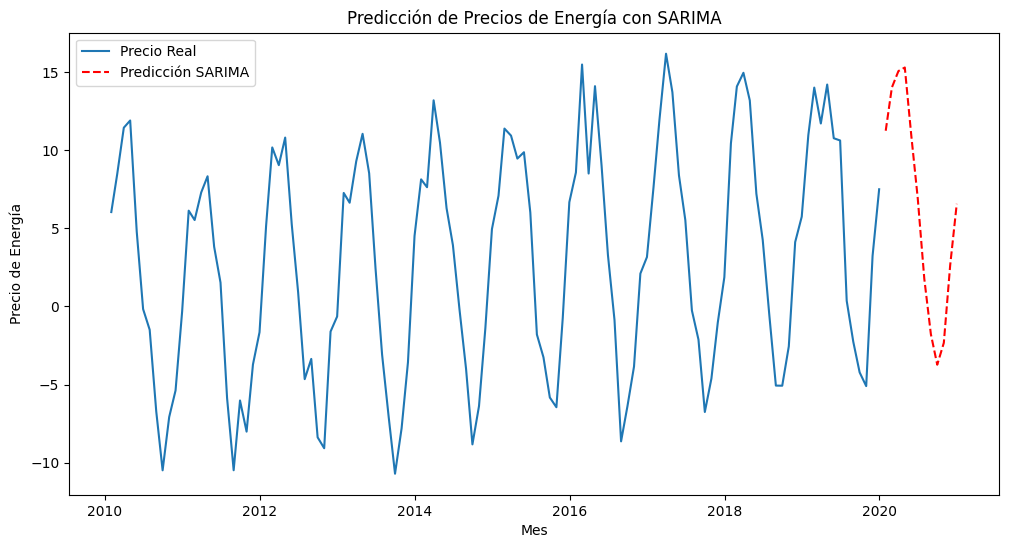

Resultados de Efectos Fijos:
                          PanelOLS Estimation Summary                           
Dep. Variable:                 Growth   R-squared:                        0.9999
Estimator:                   PanelOLS   R-squared (Between):              0.9999
No. Observations:                  50   R-squared (Within):               0.9999
Date:                Fri, Dec 13 2024   R-squared (Overall):              0.9999
Time:                        16:41:38   Log-likelihood                   -61.566
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                   2.022e+05
Entities:                          10   P-value                           0.0000
Avg Obs:                       5.0000   Distribution:                    F(2,38)
Min Obs:                       5.0000                                           
Max Obs:                       5.0000   F-statistic (robust):          2.022e+05

In [ ]:
!pip install linearmodels
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller

# Simular datos de precios de energía
np.random.seed(42)
n = 120  # Número de meses
t = np.arange(1, n + 1)
trend = 0.05 * t
seasonality = 10 * np.sin(2 * np.pi * t / 12)
noise = np.random.normal(scale=2, size=n)
energy_prices = trend + seasonality + noise

# Crear DataFrame
data_energy = pd.DataFrame({'Month': pd.date_range(start='2010-01', periods=n, freq='M'),
                            'Price': energy_prices})
data_energy.set_index('Month', inplace=True)

# Prueba de estacionariedad (ADF)
adf_test = adfuller(data_energy['Price'])
print(f"ADF Statistic: {adf_test[0]:.2f}, p-value: {adf_test[1]:.2f}")

# Modelo SARIMA
sarima_model = SARIMAX(data_energy['Price'], order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
sarima_fit = sarima_model.fit(disp=False)
print(sarima_fit.summary())

# Predicciones
forecast = sarima_fit.get_forecast(steps=12)
forecast_index = pd.date_range(start=data_energy.index[-1], periods=13, freq='M')[1:]
forecast_values = forecast.predicted_mean

# Visualización
plt.figure(figsize=(12, 6))
plt.plot(data_energy.index, data_energy['Price'], label='Precio Real')
plt.plot(forecast_index, forecast_values, label='Predicción SARIMA', linestyle='--', color='red')
plt.title('Predicción de Precios de Energía con SARIMA')
plt.xlabel('Mes')
plt.ylabel('Precio de Energía')
plt.legend()
plt.show()

import statsmodels.api as sm
from linearmodels.panel import PanelOLS, RandomEffects, compare

# Simulación de datos de panel
np.random.seed(42)
n_countries = 10
n_years = 5
index = pd.MultiIndex.from_product([range(n_countries), range(n_years)], names=["Country", "Year"])

data_panel = pd.DataFrame(index=index)
data_panel['Fiscal_Policy'] = np.random.choice([0, 1], size=len(data_panel))  # Política fiscal: 0 o 1
data_panel['Investment'] = np.random.rand(len(data_panel)) * 1000
data_panel['Growth'] = 2 + 0.5 * data_panel['Fiscal_Policy'] + 0.3 * data_panel['Investment'] + \
                       np.random.randn(len(data_panel))

# Modelo de efectos fijos
fixed_model = PanelOLS.from_formula('Growth ~ Fiscal_Policy + Investment + EntityEffects', data_panel)
fixed_results = fixed_model.fit()

# Modelo de efectos aleatorios
random_model = RandomEffects.from_formula('Growth ~ Fiscal_Policy + Investment', data_panel)
random_results = random_model.fit()

# Comparar modelos con la prueba de Hausman
results_comparison = compare({"Efectos Fijos": fixed_results, "Efectos Aleatorios": random_results})

# Visualización de los resultados
print("Resultados de Efectos Fijos:")
print(fixed_results.summary)
print("\nResultados de Efectos Aleatorios:")
print(random_results.summary)
print("\nComparación de Modelos:")
print(results_comparison)
